# Imports and setup

In [79]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import plotly.express as px
import h5py
import torch
from pathlib import Path

In [80]:
sns.set_theme(font='Arial', font_scale=1.2, style='white', palette=px.colors.qualitative.Plotly)
# sns.set_theme(font='Arial', font_scale=1.2, style='white', palette=sns.color_palette("cubehelix"))
sns.set_style(rc={
    # 'axes.edgecolor': 'gray',
    'axes.linewidth': 0.5,
    'xtick.bottom': True,
    'ytick.left': True,
    'svg.fonttype': 'none'
    })

In [81]:
paper_pt_dict = {'S14': 'S1', 'S26': 'S2', 'S33': 'S3', 'S22': 'S4', 'S23': 'S5', 'S39': 'S6', 'S58': 'S7', 'S62': 'S8'}

In [82]:
DATA_DIR = Path('../../data/')
FIG_DIR = Path('~/Box/Coganlab/Papers/2025/cross-patient-speech-decoding/figures/supp/CTC_log_fit').expanduser()
ctc_res_dir = DATA_DIR / 'results' / 'decoding' / 'ctc_results_90varNoDel_computeAlign_augs'

# Log fit to cross-patient-subsampled data

### Plotting utils

In [83]:
to_cm = 1/2.54

In [84]:
px_colors = [
             '#636EFA',
             '#EF553B',
             '#AB63FA',
             '#00CC96',
            #  '#72B7B2',
            #  '#990099',
            #  '#B6E880',

             
            #  '#FFA15A',
            #  '#19D3F3',
            #  '#FF6692',
            #  '#B6E880',
            #  '#FF97FF',
            #  '#FECB52',
            ]

In [85]:
# sns.set_theme(context='notebook', font='Arial', font_scale=1.15)
sns.set_theme(font='Arial', font_scale=1.2, style='white', palette=px_colors)
sns.set_style(rc={
    # 'axes.edgecolor': 'gray',
    'axes.linewidth': 0.5,
    'xtick.bottom': True,
    'ytick.left': True,
    'svg.fonttype': 'none',
    })
plt.rcParams['svg.fonttype'] = 'none'

### Log fit to cross-patient sampling

In [86]:
res_pts = ['S14', 'S26', 'S22', 'S23', 'S39', 'S58', 'S62']
contexts = {'Chance': '_chance', 'Patient-specific': '_ptSpecific', 'Unaligned': '_unaligned', 'Aligned': '_aligned'}
tw = [0.5, 3.5]

ctc_decode_df = pd.DataFrame()
for pt in res_pts:
    skip_outer = False

    pers = np.empty((len(contexts), 100)) * np.nan
    for i, (context, c_suffix) in enumerate(contexts.items()):
        res_path = ctc_res_dir / f'{pt}/{pt}_ctcRNN_decodeTW([{tw[0]},{tw[1]}]){c_suffix}.h5'
        try:
            with h5py.File(res_path, 'r') as f:
                pers_data = f['phoneme_error_rate'][:]
                pers[i, :len(pers_data)] = pers_data
        except FileNotFoundError:
            print(f'{str(res_path)} not found. Skipping patient {pt}.')
            skip_outer=True
            # break
    
    if skip_outer:
        continue
        
    pt_df = pd.DataFrame(pers.T, columns=list(contexts.keys()))
    pt_df = pt_df.dropna()
    pt_df = pt_df.melt(var_name='Decoding type', value_name='Phoneme error rate')
    pt_df['Patient'] = paper_pt_dict[pt]
    ctc_decode_df = pd.concat([ctc_decode_df, pt_df], axis=0)
ctc_decode_df.reset_index(drop=True, inplace=True)
ctc_decode_df

,Decoding type,Phoneme error rate,Patient
0,Chance,86.538462,S1
1,Chance,83.333333,S1
2,Chance,84.615385,S1
3,Chance,84.615385,S1
4,Chance,87.179487,S1
...,...,...,...
1395,Aligned,86.538462,S8
1396,Aligned,83.333333,S8
1397,Aligned,79.487179,S8
1398,Aligned,82.051282,S8


In [87]:
res_pts = ['S14', 'S26', 'S22', 'S23',  'S39', 'S58', 'S62']
contexts = {'Aligned': '_aligned'}
tw = [0.5, 3.5]
avg_tr_duration = 3.75 / 60 # minutes

cps_ctc_df = pd.DataFrame()
for pt in res_pts:
    skip_outer = False
    pers = np.empty((len(contexts), 100)) * np.nan
    for i, (context, c_suffix) in enumerate(contexts.items()):
        res_path = ctc_res_dir / f'{pt}/{pt}_ctcRNN_decodeTW([{tw[0]},{tw[1]}]){c_suffix}_crossPatientSubsamp.h5'
        try:
            with h5py.File(res_path, 'r') as f:
                for trial_str in [f for f in f.keys() if 'num_trials' in f]:
                    k_trials = int(trial_str.split('_')[-1])
                    pers_data = f[trial_str]['phoneme_error_rate'][:]
                    pers[i, :len(pers_data)] = pers_data

                    pt_df = pd.DataFrame(pers.T, columns=list(contexts.keys()))
                    pt_df = pt_df.dropna()
                    pt_df = pt_df.melt(var_name='Decoding type', value_name='Phoneme error rate')
                    pt_df['Patient'] = paper_pt_dict[pt]
                    pt_df['Cross-patient trials'] = k_trials
                    pt_df['Cross-patient data (min.)'] = k_trials * avg_tr_duration
                    pt_df['Cross-patient data (hours)'] = pt_df['Cross-patient data (min.)'] / 60
                    cps_ctc_df = pd.concat([cps_ctc_df, pt_df], axis=0)
        except FileNotFoundError:
            print(f'{str(res_path)} not found.')
            skip_outer = True
            break
    if skip_outer:
        continue

cps_ctc_df.reset_index(drop=True, inplace=True)
cps_ctc_df

,Decoding type,Phoneme error rate,Patient,Cross-patient trials,Cross-patient data (min.),Cross-patient data (hours)
0,Aligned,79.487179,S1,105,6.5625,0.109375
1,Aligned,72.435897,S1,105,6.5625,0.109375
2,Aligned,78.846154,S1,105,6.5625,0.109375
3,Aligned,75.641026,S1,105,6.5625,0.109375
4,Aligned,74.358974,S1,105,6.5625,0.109375
...,...,...,...,...,...,...
5245,Aligned,85.897436,S8,921,57.5625,0.959375
5246,Aligned,80.769231,S8,921,57.5625,0.959375
5247,Aligned,77.564103,S8,921,57.5625,0.959375
5248,Aligned,85.256410,S8,921,57.5625,0.959375


In [88]:
mean_cps_df = cps_ctc_df.groupby(['Cross-patient trials', 'Decoding type', 'Patient']).mean().reset_index()

In [89]:
lr_cps_df = mean_cps_df.drop(columns=['Decoding type', 'Patient']).groupby('Cross-patient data (min.)').mean()

log_x = mean_cps_df['Cross-patient data (min.)'].unique()
log_y = np.log(lr_cps_df['Phoneme error rate'].values)

log_res = stats.linregress(log_x, log_y)
print(f'LR on log transformed data: slope = {log_res.slope}, r2 = {log_res.rvalue**2}, p = {log_res.pvalue}')

log_x_proj = np.arange(0, 2000, 5)
log_y_proj = np.exp(log_res.intercept + log_res.slope * log_x_proj)

print(f'{log_x_proj[np.where(log_y_proj <= 25)[0][0]]} min. cross-patient data yield a PER of 25%')
print(f'{log_x_proj[np.where(log_y_proj <= 10)[0][0]]} min. cross-patient data yield a PER of 10%')

LR on log transformed data: slope = -0.0014203182437859377, r2 = 0.975928445758542, p = 6.621875221140612e-12
875 min. cross-patient data yield a PER of 25%
1520 min. cross-patient data yield a PER of 10%


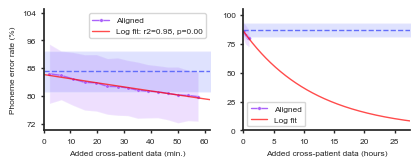

In [94]:
f, (ax1, ax2) = plt.subplots(1,2,figsize=(12*to_cm,4*to_cm))

formatter = ticker.FuncFormatter(lambda x, pos: f"{x:.2f}".rstrip('0').rstrip('.'))

sns.lineplot(data=mean_cps_df, x='Cross-patient data (min.)', y='Phoneme error rate',
             hue='Decoding type', marker='o', errorbar='sd', palette=['#AB63FA'],
             markersize=2.5, markeredgewidth=0.2, linewidth=1, err_kws={'edgecolor': None},
             ax=ax1)

ps_mean = ctc_decode_df[ctc_decode_df['Decoding type'] == 'Patient-specific']['Phoneme error rate'].mean()
ps_std = ctc_decode_df[ctc_decode_df['Decoding type'] == 'Patient-specific']['Phoneme error rate'].std()
ax1.axhline(ps_mean, color='#636EFA', linestyle='--', linewidth=1)
ax1.fill_between((-5,65), ps_mean - ps_std, ps_mean + ps_std, color='#636EFA', alpha=0.2, edgecolor=None)

sns.lineplot(x=log_x_proj, y=log_y_proj, color='red', label=f'Log fit: r2={log_res.rvalue**2:.2f}, p={log_res.pvalue:.2f}', ax=ax1, linewidth=1, alpha=0.7)

ax1.set_xlabel('Added cross-patient data (min.)', fontsize=6)
ax1.set_ylabel('Phoneme error rate (%)', fontsize=6)
ax1.set_ylim([70,105])
ax1.set_xlim([0,62])
ax1.legend(fontsize=6)
ax1.set_xticks(np.arange(0, 61, 10), labels=np.arange(0, 61, 10), fontsize=6)
ax1.tick_params(axis='both', which='major', length=2, width=1)
ax1.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
ax1.yaxis.set_major_formatter(formatter)
for label in ax1.get_xticklabels() + ax1.get_yticklabels():
        label.set_fontsize(6)

sns.lineplot(data=mean_cps_df, x='Cross-patient data (hours)', y='Phoneme error rate',
             hue='Decoding type', marker='o', errorbar='sd', palette=['#AB63FA'],
             markersize=2.5, markeredgewidth=0.2, linewidth=1, err_kws={'edgecolor': None},
             ax=ax2)

ps_mean = ctc_decode_df[ctc_decode_df['Decoding type'] == 'Patient-specific']['Phoneme error rate'].mean()
ps_std = ctc_decode_df[ctc_decode_df['Decoding type'] == 'Patient-specific']['Phoneme error rate'].std()
ax2.axhline(ps_mean, color='#636EFA', linestyle='--', linewidth=1)
ax2.fill_between((-5,30), ps_mean - ps_std, ps_mean + ps_std, color='#636EFA', alpha=0.2, edgecolor=None)

sns.lineplot(x=log_x_proj/60, y=log_y_proj, color='red', label='Log fit', ax=ax2, linewidth=1, alpha=0.7)

ax2.set_xlabel('Added cross-patient data (hours)', fontsize=6)
ax2.set_ylabel('', fontsize=6)
ax2.set_ylim([0,105])
ax2.set_xlim([0,27.5])
ax2.legend(fontsize=6)
ax2.tick_params(axis='both', which='major', length=2, width=1)
ax2.set_xticks(np.arange(0, 26, 5), labels=np.arange(0, 26, 5), fontsize=6)
ax2.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
ax2.yaxis.set_major_formatter(formatter)
for label in ax2.get_xticklabels() + ax2.get_yticklabels():
        label.set_fontsize(6)
sns.despine()

plt.savefig(FIG_DIR / 'ctcRNN_crossPtSubsamp_logFit.svg', format='svg')
plt.show()